## Figure 1 - Dataset Summary / Experimental Overview

This script generates Figure 1 which provides an overview of the platform dataset,
including cell counts, imaging depths, and example stimulus/behavior timeseries data.

Figure panels:
  - Panel A: Example max intensity projection and ROI outlines
  - Panel B: Stimulus blocks + all traces heatmap + behavior timeseries (combined multi-panel)
  - Panel C: Cell count histograms by depth for the platform dataset
  - Panel D: Number of cells per plane by depth
  - Panel E: Number of planes per depth

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

import visual_behavior.data_access.utilities as utilities
from visual_behavior.data_access import loading as loading

import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

/opt/conda/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/capsule/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/root/capsule/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)


In [3]:
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

# Get or create save directory using relative path
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_1')
os.makedirs(save_dir, exist_ok=True)

folder = 'dataset_summary'

### Data Loading

Load cache and get experiment/cell tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = VisualBehaviorOphysProjectCache.from_local_cache(cache_dir=platform_cache_dir, use_static_cache=True)

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
palette = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


### Dataset stats

Note that the numbers below do not include the cohort of mice with 2 holdover familiar images included in the novel session, under project code = `VisualBehaviorMultiscope4areasx2d`. That set of mice has a unique experimental design and was not analyzed as part of the Visual Behavior Ophys platform paper. It is wide open for others to study! 

In this study, each session has only familiar or only novel images. 

In [4]:
print(len(experiments_table.mouse_id.unique()), 'mice')
print(len(experiments_table.ophys_session_id.unique()), 'sessions')
print(len(experiments_table.ophys_container_id.unique()), 'containers')
print(len(experiments_table.index.unique()), 'experiments')

NameError: name 'experiments_table' is not defined

In [5]:
print(len(platform_cells_table.mouse_id.unique()), 'mice')
print(len(platform_cells_table.ophys_experiment_id.unique()), 'expriments')
print(len(platform_cells_table.ophys_session_id.unique()), 'sessions')
print(len(platform_cells_table.ophys_container_id.unique()), 'containers')
print(len(platform_cells_table.cell_specimen_id.unique()), 'cells')

NameError: name 'platform_cells_table' is not defined

In [6]:
print(len(matched_cells_table.ophys_experiment_id.unique()), 'experiments')
print(len(matched_cells_table.ophys_session_id.unique()), 'sessions')
print(len(matched_cells_table.ophys_container_id.unique()), 'containers')
print(len(matched_cells_table.cell_specimen_id.unique()), 'matched cells')

393 experiments
199 sessions
131 containers
3917 matched cells


#### Per cre line

In [6]:
unique_cells = platform_cells_table.drop_duplicates('cell_specimen_id')
cell_counts = unique_cells.groupby(['cell_type']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

NameError: name 'platform_cells_table' is not defined

In [8]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=['cell_type'], include_matched_cells=True)
    

,n_mouse_id,n_ophys_session_id,n_ophys_experiment_id,n_ophys_container_id,n_cell_specimen_id,n_matched_cells
cell_type,,,,,,
Excitatory,34,103,186,62,12826,3306
Sst Inhibitory,15,46,90,30,468,200
Vip Inhibitory,17,53,126,42,1197,411


In [9]:
utilities.count_mice_expts_containers_cells(platform_cells_table, 
                                            conditions_to_group=['cell_type', 'binned_depth'], include_matched_cells=True)
    

n_mouse_id  n_ophys_session_id  \
cell_type      binned_depth                                   
Excitatory     75                     4                  12   
               175                   17                  51   
               275                    7                  22   
               375                   19                  57   
Sst Inhibitory 75                     3                   9   
               175                    3                   9   
               275                   14                  43   
               375                    3                   9   
Vip Inhibitory 75                     6                  19   
               175                   17                  51   
               275                    6                  20   
               375                    3                   9   

                             n_ophys_experiment_id  n_ophys_container_id  \
cell_type      binned_depth                                                
Excitatory     75                               21                     7   
               175                              60                    20   
               275                              42                    14   
               375                              63                    21   
Sst Inhibitory 75                                9                     3   
               175                              12                     4   
               275                              60                    20   
               375                               9                     3   
Vip Inhibitory 75                               24                     8   
               175                              54                    18   
               275                              39                    13   
               375                               9                     3   

                             n_cell_specimen_id  n_matched_cells  
cell_type      binned_depth                                       
Excitatory     75                           692              125  
               175                         4860             1315  
               275                         3489              748  
               375                         3785             1118  
Sst Inhibitory 75                            65               14  
               175                           69               35  
               275                          302              145  
               375                           32                6  
Vip Inhibitory 75                           266               93  
               175                          569              204  
               275                          310               98  
               375                           52               16

#### By depth and cohort

In [10]:
cell_counts = platform_cells_table.groupby(['cell_type',  'project_code', 'binned_depth']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

n_cells
cell_type      project_code             binned_depth         
Excitatory     VisualBehavior           175              2615
                                        375              3479
               VisualBehaviorMultiscope 75               1130
                                        175              2999
                                        275              5891
                                        375              1223
               VisualBehaviorTask1B     175              3067
                                        375              2276
Sst Inhibitory VisualBehavior           275               238
               VisualBehaviorMultiscope 75                109
                                        175               153
                                        275               291
                                        375                54
               VisualBehaviorTask1B     275               133
Vip Inhibitory VisualBehavior           175               468
               VisualBehaviorMultiscope 75                502
                                        175               408
                                        275               564
                                        375                92
               VisualBehaviorTask1B     175               231

In [11]:
cell_counts = platform_cells_table.groupby(['cell_type', 'binned_depth']).count().rename(columns={'cell_specimen_id':'n_cells'})[['n_cells']]
cell_counts

n_cells
cell_type      binned_depth         
Excitatory     75               1130
               175              8681
               275              5891
               375              6978
Sst Inhibitory 75                109
               175               153
               275               662
               375                54
Vip Inhibitory 75                502
               175              1107
               275               564
               375                92

### Panel A: Example max intensity projections for all sessions for one mouse

NOTE: This panel requires a specific dataset_dict which needs to be generated
by loading data for a specific mouse and session. This is commented out as it
requires substantial memory and specific dataset configuration.

To generate this panel:
1. Select a mouse_id and ophys_session_id
2. Load the dataset_dict using loading.get_dataset_dict_for_containers()
3. Call plot_roi_mask_outlines() on the desired container/experiment

Load dataset for example mouse and session

In [12]:
# mice with a good session order and all / most planes 
good_session_sequence_mice = [449653, # Vip (from example), has 7 planes, 5 sessions out of order (missing novel passive)
                        453988, # Vip, same conditions as the mouse above
                        484627, # Slc,  has all 8 planes, sessions in perfect order
                        479839, # Slc, has all 8 planes, sessions slightly out of order but could be rearranged
                        485152, # Slc, has 7 planes, slightly out of order
                        ]
# count number of experiments per session for each mouse
# experiments_table[(experiments_table.mouse_id.isin(good_session_sequence_mice))].groupby(['mouse_id', 'cre_line', 'date_of_acquisition','session_type']).count()

In [13]:
mouse_id = 449653
# mouse_id = 484627

mouse_expts = experiments_table[experiments_table.mouse_id==mouse_id].sort_values(by=['date_of_acquisition', 'targeted_structure', 'imaging_depth'])
ophys_container_ids = mouse_expts.ophys_container_id.unique()

dataset_dict = loading.get_dataset_dict_for_containers(
    ophys_container_ids,
    mouse_expts,
    dataset_dict=None)

875564420


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded v

872499160


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded v

873970535


...

/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded v

877669815


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded v

877057341


/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded v

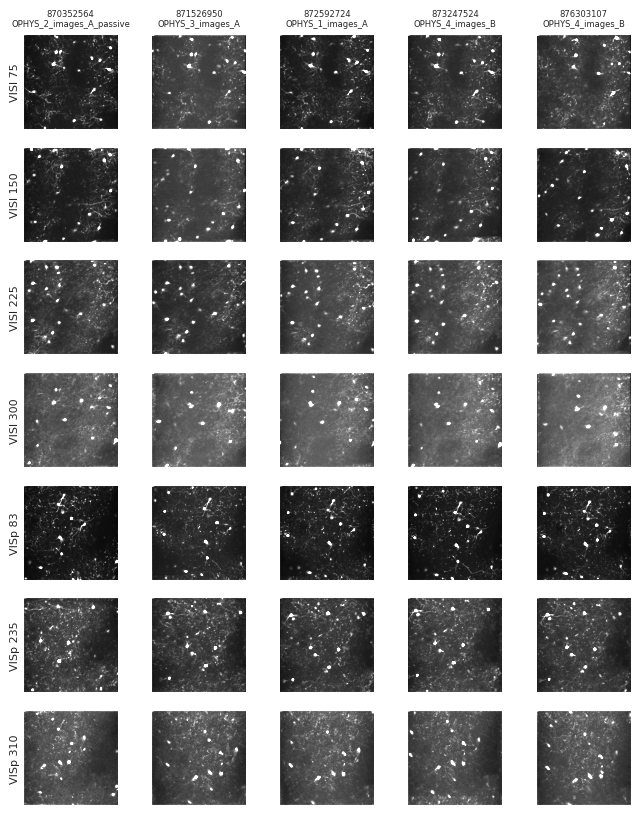

In [14]:
# Plot max projections with ROI outlines for all FOVs across sessions for one mouse
session_id_for_area_depths = mouse_expts.ophys_session_id.unique()[0]
ppf.plot_all_planes_all_sessions_for_mouse(dataset_dict, mouse_expts, session_id_for_area_depths,
                                           save_dir=save_dir, folder='max_projection_images', ax=None)


In [1]:
# Plot matched ROIs and max projections for a specific container
# Just for the sessions included in paper analysis (one Familiar, first Novel, second Novel)
ophys_container_id = mouse_expts.ophys_container_id.unique()[5]
ophys_experiment_id = mouse_expts[mouse_expts.ophys_container_id == ophys_container_id].index.values[0]
cell_specimen_ids = matched_cells_table[matched_cells_table.ophys_container_id==ophys_container_id].cell_specimen_id.unique()
print(len(cell_specimen_ids))
# Plot max projection with ROI outlines
pse.plot_max_and_roi_outlines_for_container(ophys_container_id, platform_experiments,
                                            dataset_dict, cell_specimen_ids, save_dir=save_dir, ax=None)


IndentationError: unexpected indent (1009967036.py, line 10)

### Panel B: Stimulus blocks + All traces heatmap + Behavior timeseries 
This section loads data for an example session and creates a combined figure
with stimulus blocks, neural traces heatmap, and behavior timeseries

Select mouse and filter to sessions with good data

In [ ]:
# Get data for the first novel session
session_expts = mouse_expts[(mouse_expts.session_type == 'OPHYS_4_images_B') &
                             (mouse_expts.experience_level == 'Novel 1')]
ophys_container_ids = session_expts.ophys_container_id.unique()

# Aggregate traces for this session
all_traces, session_metadata = ppf.aggregate_traces_for_session(
    dataset_dict, session_expts, trace_type='dff')

# Get a representative container for the combined plot
ophys_container_id = session_expts.ophys_container_id.unique()[0]
ophys_experiment_id = session_expts[session_expts.ophys_container_id == ophys_container_id].index.values[0]
ophys_session_id = session_expts.ophys_session_id.unique()[0]

dataset = dataset_dict[ophys_container_id][ophys_experiment_id]
stim_table = dataset.stimulus_presentations.copy()
timestamps = dataset.ophys_timestamps.copy()
xlim_seconds = [timestamps[0], timestamps[-1]]

# Create combined figure with stimulus blocks, traces heatmap, and behavior
figsize = [16, 12]
fig = plt.figure(figsize=figsize, facecolor='white')

# Sub-panel B1: Stimulus blocks
ax = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 0.75), yspan=(0, 0.08))
ax = ppf.add_stimulus_blocks(stim_table, xlim=xlim_seconds, annotate_blocks=True, ax=ax)
ax.set_xticklabels('')
ax.set_xlabel('')

# Sub-panel B2: All traces heatmap
ax = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 1), yspan=(0.12, 0.65))
ax = ppf.plot_all_traces_heatmap(all_traces, session_metadata, timestamps=timestamps,
                                  cmap='gray_r', save_dir=None, ax=ax)
ax.set_xticklabels('')
ax.set_xlabel('')

# Sub-panel B3: Simple behavior timeseries (non-stacked)
ax_behavior = utils.placeAxesOnGrid(fig, dim=(1, 1), xspan=(0, 0.75), yspan=(0.68, 0.72))
ax_behavior = ppf.plot_behavior_timeseries(dataset, start_time=timestamps[0],
                                           xlim_seconds=xlim_seconds, save_dir=None, ax=ax_behavior)
ax_behavior.set_xticklabels('')
ax_behavior.set_xlabel('')

# Sub-panel B4-B6: Behavior timeseries (stacked format with 4 subplots)
ax = utils.placeAxesOnGrid(fig, dim=(4, 1), xspan=(0, 0.75), yspan=(0.7, 1),
                            sharex=True, height_ratios=[1, 1, 3, 3])
ax = ppf.plot_behavior_timeseries_stacked(dataset, start_time=timestamps[0],
                                           xlim_seconds=xlim_seconds,
                                           show_images=False, label_changes=False,
                                           label_omissions=False, save_dir=None, ax=ax)

# Save the combined figure
folder_combined = 'combined_panels'
utils.save_figure(fig, figsize, save_dir, folder_combined,
                  str(mouse_id) + '_' + str(ophys_session_id) + '_traces_and_behavior')

IndexError: index 0 is out of bounds for axis 0 with size 0

#### Plot behavior and ophys timeseries for one session

/opt/conda/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded v

saving


array([<Axes: title={'center': '425496_808621034_Slc17a7_VISp_175_OPHYS_4_images_B'}>,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: ylabel='running\nspeed\n(cm/s)'>,
       <Axes: ylabel='pupil\ndiameter\n(pixels)'>, <Axes: ylabel='licks'>,
       <Axes: xlabel='Time in session (seconds)', ylabel='rewards'>],
      dtype=object)

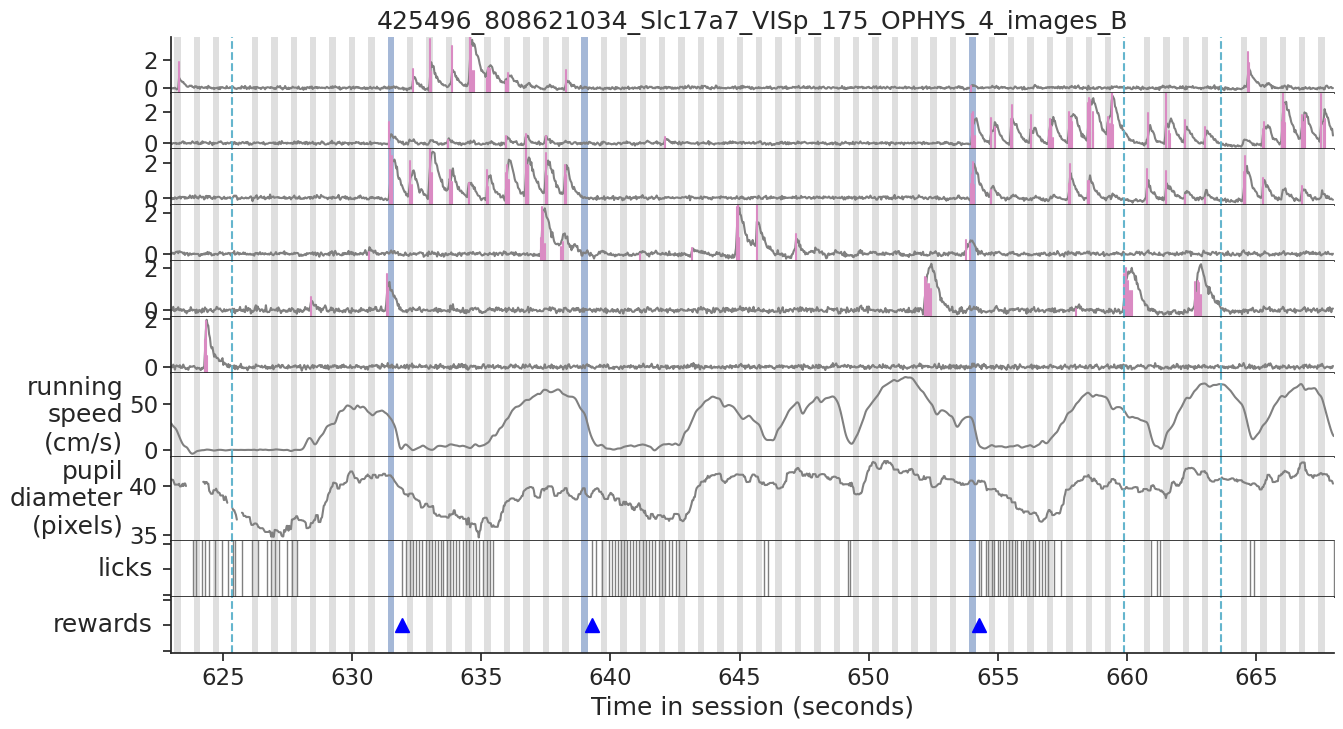

In [ ]:
ophys_experiment_id = 808621034
dataset = loading.get_ophys_dataset(ophys_experiment_id)

trials = dataset.trials.copy()
start_times = trials[trials.is_change].start_time.values
start_time = start_times[10]

ppf.plot_behavior_and_physio_timeseries_stacked(dataset, start_time=628, duration_seconds=20, save_dir=save_dir, ax=None)

In [ ]:
ppf.plot_n_planes_per_depth(tmp, suptitle=suptitle, save_dir=save_dir,
                            folder=folder, ax=None)

## Composite Figure 1: All panels on a single figure axis

Layout based on published Figure 1 (Allen Brain Observatory Visual Behavior 2P dataset):
- **Row 1**: A (pipeline schematic) | D (active/passive sessions) | E (image sets)
- **Row 2**: B (GCaMP6 cell images) | C (multi-plane longitudinal imaging)
- **Row 3**: F (full session: stimulus blocks + traces heatmap + behavior)

Panels A, D, E are schematics — left as labeled placeholders for Illustrator.
Saves as PDF for Illustrator editing.

In [ ]:
def plot_figure_1_composite(dataset_dict, session_expts, mouse_expts, mouse_id,
                            ophys_session_id, ophys_container_id, ophys_experiment_id,
                            all_traces, session_metadata, dataset, stim_table, timestamps,
                            platform_cells_table, platform_experiments, matched_cells_table,
                            save_dir=None, folder='composite_figures'):
    """Generate a composite Figure 1 with all panels in the published layout. Saved as PDF."""
    figsize = (22, 22)
    fig = plt.figure(figsize=figsize, facecolor='white')

    # Row 1: Panels A, D, E (schematics — placeholders)
    ax_A = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0, 0.55], yspan=[0, 0.12])
    ax_A.text(0.5, 0.5, 'A — Pipeline schematic\n(place manually)', transform=ax_A.transAxes,
              ha='center', va='center', fontsize=11, color='gray')
    ax_A.set_title('A', loc='left', fontweight='bold', fontsize=16); ax_A.axis('off')

    ax_D = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.58, 0.78], yspan=[0, 0.12])
    ax_D.text(0.5, 0.5, 'D — Active/passive\nsessions schematic', transform=ax_D.transAxes,
              ha='center', va='center', fontsize=10, color='gray')
    ax_D.set_title('D', loc='left', fontweight='bold', fontsize=16); ax_D.axis('off')

    ax_E = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.80, 1.0], yspan=[0, 0.12])
    ax_E.text(0.5, 0.5, 'E — Familiar/novel\nimage sets', transform=ax_E.transAxes,
              ha='center', va='center', fontsize=10, color='gray')
    ax_E.set_title('E', loc='left', fontweight='bold', fontsize=16); ax_E.axis('off')

    # Row 2: Panel B (GCaMP images) | Panel C (multi-plane longitudinal)
    ax_B = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0, 0.25], yspan=[0.15, 0.32])
    try:
        pse.plot_roi_mask_outlines(dataset, cell_specimen_ids=None, ax=ax_B)
    except Exception:
        pass
    ax_B.set_title('B', loc='left', fontweight='bold', fontsize=16)

    ax_C = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.28, 1.0], yspan=[0.15, 0.32])
    ax_C.text(0.5, 0.5, 'C — Multi-plane longitudinal imaging\n(place manually)',
              transform=ax_C.transAxes, ha='center', va='center', fontsize=11, color='gray')
    ax_C.set_title('C', loc='left', fontweight='bold', fontsize=16); ax_C.axis('off')

    # Row 3: Panel F (full session traces + behavior)
    xlim_seconds_F = [timestamps[0], timestamps[-1]]

    ax_F1 = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.05, 0.85], yspan=[0.36, 0.40])
    ax_F1 = ppf.add_stimulus_blocks(stim_table, xlim=xlim_seconds_F, annotate_blocks=True, ax=ax_F1)
    ax_F1.set_xticklabels(''); ax_F1.set_xlabel('')
    ax_F1.set_title('F', loc='left', fontweight='bold', fontsize=16)

    ax_F2 = utils.placeAxesOnGrid(fig, dim=[1, 1], xspan=[0.05, 1.0], yspan=[0.42, 0.75])
    ax_F2 = ppf.plot_all_traces_heatmap(all_traces, session_metadata, timestamps=timestamps,
                                         cmap='gray_r', save_dir=None, ax=ax_F2)
    ax_F2.set_xticklabels(''); ax_F2.set_xlabel('')

    ax_F3 = utils.placeAxesOnGrid(fig, dim=[4, 1], xspan=[0.05, 0.85], yspan=[0.77, 0.98],
                                   sharex=True, height_ratios=[1, 1, 3, 3])
    ax_F3 = ppf.plot_behavior_timeseries_stacked(dataset, start_time=timestamps[0],
                                                  xlim_seconds=xlim_seconds_F,
                                                  show_images=False, label_changes=False,
                                                  label_omissions=False, save_dir=None, ax=ax_F3)

    if save_dir:
        utils.save_figure(fig, figsize, save_dir, folder, 'figure_1_composite', formats=['.pdf'])
    return fig

# Generate composite figure
fig1 = plot_figure_1_composite(
    dataset_dict, session_expts, mouse_expts, mouse_id,
    session_id_for_area_depths, ophys_container_id, ophys_experiment_id,
    all_traces, session_metadata, dataset, stim_table, timestamps,
    platform_cells_table, platform_experiments, matched_cells_table,
    save_dir=save_dir, folder='composite_figures')


NameError: name 'session_expts' is not defined